In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# load data; filter by product and timeframe
file_name = ".\\r0_d-1.csv"
df = pd.read_csv(file_name, delimiter=";")
df = df[df['product'] == 'TOMATOES']
low, high = map(int, input().split())
df = df[(df['timestamp'] >= low) & (df['timestamp'] <= high)]

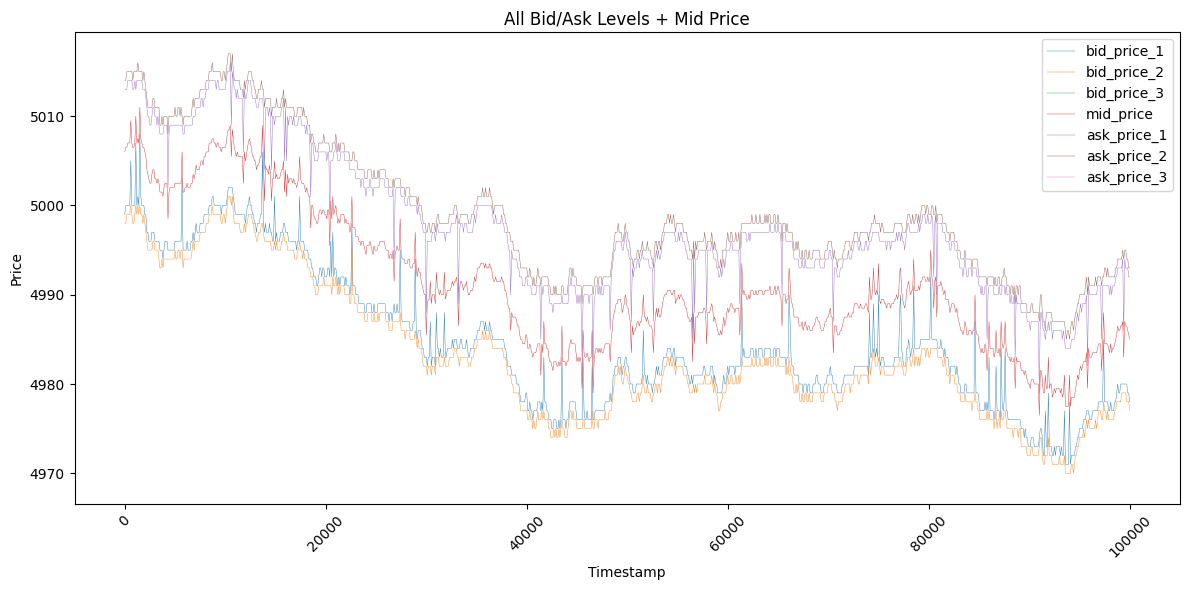

In [2]:

# plot 7 price levels
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['bid_price_1'], label='bid_price_1', lw = 0.3)
plt.plot(df['timestamp'], df['bid_price_2'], label='bid_price_2', lw = 0.3)
plt.plot(df['timestamp'], df['bid_price_3'], label='bid_price_3', lw = 0.3)
plt.plot(df['timestamp'], df['mid_price'], label='mid_price', lw = 0.3)
plt.plot(df['timestamp'], df['ask_price_1'], label='ask_price_1', lw = 0.3)
plt.plot(df['timestamp'], df['ask_price_2'], label='ask_price_2', lw = 0.3)
plt.plot(df['timestamp'], df['ask_price_3'], label='ask_price_3', lw = 0.3)
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.title('All Bid/Ask Levels + Mid Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

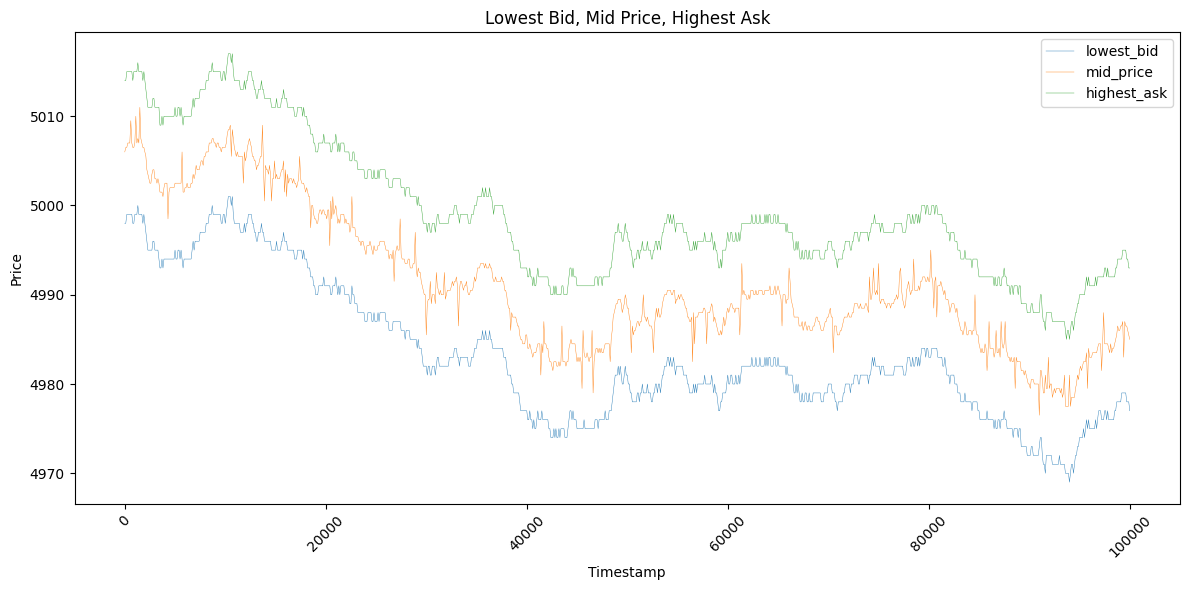

In [3]:

# lowest bid, mid price, highest ask
lowest_bid = df[['bid_price_1', 'bid_price_2', 'bid_price_3']].min(axis=1)
highest_ask = df[['ask_price_1', 'ask_price_2', 'ask_price_3']].max(axis=1)
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], lowest_bid, label='lowest_bid', lw = 0.3)
plt.plot(df['timestamp'], df['mid_price'], label='mid_price', lw = 0.3)
plt.plot(df['timestamp'], highest_ask, label='highest_ask', lw = 0.3)
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.title('Lowest Bid, Mid Price, Highest Ask')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

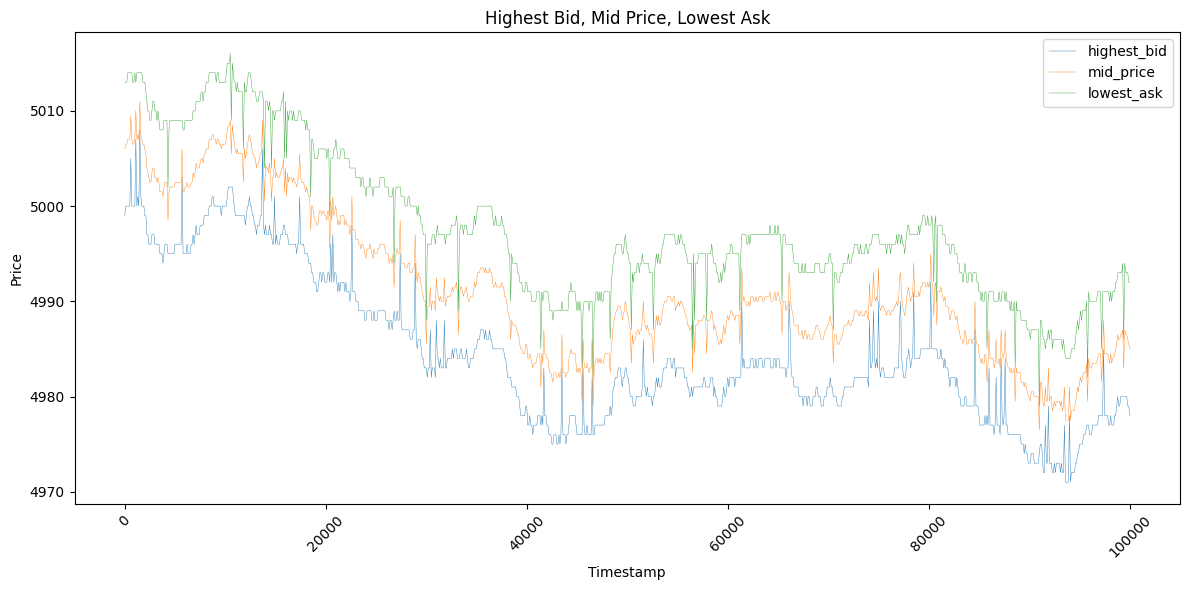

In [4]:

# highest bid, mid price, lowest ask
highest_bid = df[['bid_price_1', 'bid_price_2', 'bid_price_3']].max(axis=1)
lowest_ask = df[['ask_price_1', 'ask_price_2', 'ask_price_3']].min(axis=1)
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], highest_bid, label='highest_bid', lw = 0.3)
plt.plot(df['timestamp'], df['mid_price'], label='mid_price', lw = 0.3)
plt.plot(df['timestamp'], lowest_ask, label='lowest_ask', lw = 0.3)
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.title('Highest Bid, Mid Price, Lowest Ask')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

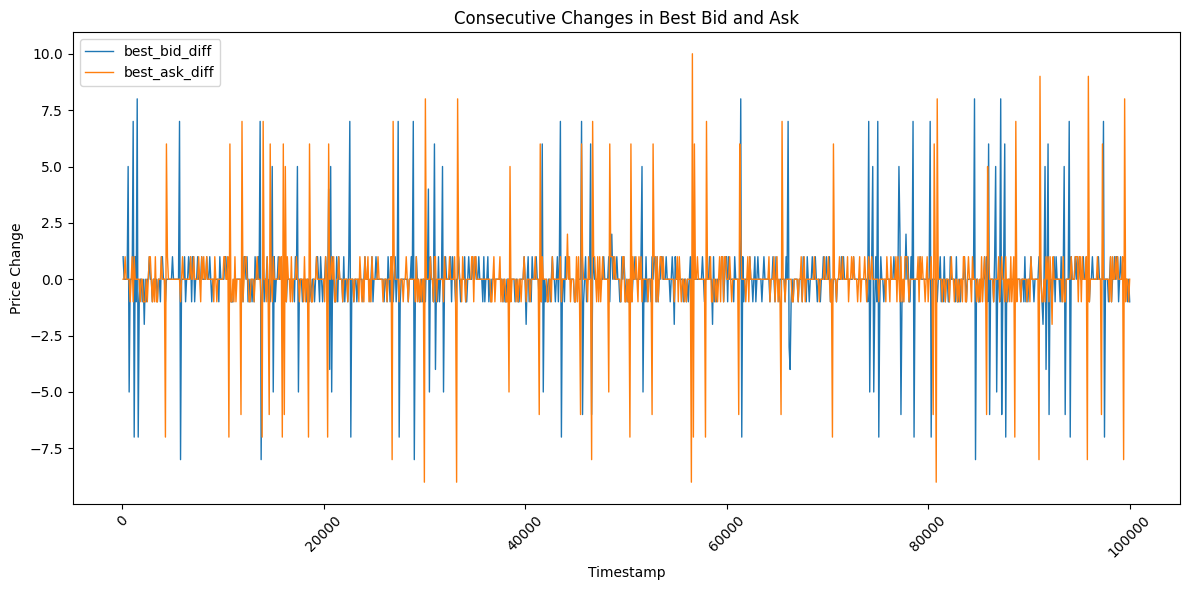

In [5]:
# plot differences in best bid + ask to find signal --> +/- 2.5!
best_bid = df[['bid_price_1', 'bid_price_2', 'bid_price_3']].max(axis=1)
best_ask = df[['ask_price_1', 'ask_price_2', 'ask_price_3']].min(axis=1)
best_bid_diff = best_bid.diff()
best_ask_diff = best_ask.diff()
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], best_bid_diff, label='best_bid_diff', lw=1)
plt.plot(df['timestamp'], best_ask_diff, label='best_ask_diff', lw=1)
plt.xlabel('Timestamp')
plt.ylabel('Price Change')
plt.title('Consecutive Changes in Best Bid and Ask')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

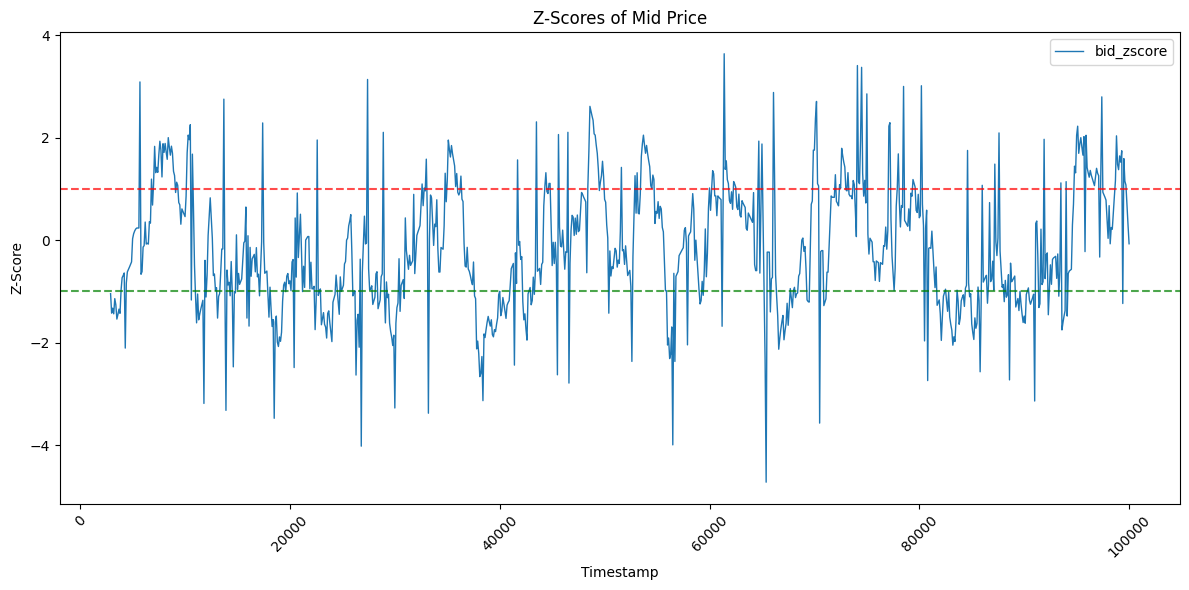

In [8]:
# best bid and ask
best_bid = df[['bid_price_1', 'bid_price_2', 'bid_price_3']].max(axis=1)
best_ask = df[['ask_price_1', 'ask_price_2', 'ask_price_3']].min(axis=1)
mid_price = (best_bid + best_ask) / 2

# rolling z-scores
window = 30  # adjust as needed
mid_mean = mid_price.rolling(window).mean()
mid_std = mid_price.rolling(window).std()
z_score = (mid_price - mid_mean) / mid_std

# plot z-scores
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], z_score, label='bid_zscore', lw=1)
plt.axhline(1, linestyle='--', color='red', alpha=0.7)
plt.axhline(-1, linestyle='--', color='green', alpha=0.7)
plt.xlabel('Timestamp')
plt.ylabel('Z-Score')
plt.title('Z-Scores of Mid Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()